In [41]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt

years = 15

endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*years)

tickers = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [42]:
#Download Adjusted Close Prices and Calculate Log Returns
adj_close_df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker, start=startDate, end=endDate)
    adj_close_df[ticker] = data['Adj Close']

log_returns = np.log(adj_close_df / adj_close_df.shift(1))
log_returns = log_returns.dropna()
log_returns.head()

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


,SPY,BND,GLD,QQQ,VTI
Date,,,,,
2009-06-16,-0.013655,0.004676,0.009070,-0.009798,-0.014022
2009-06-17,-0.000983,-0.000519,0.004558,0.009519,-0.001305
2009-06-18,0.007292,-0.007416,-0.008045,-0.001952,0.005424
2009-06-19,0.003679,0.002348,0.003161,0.010676,0.003671
2009-06-22,-0.030446,0.002342,-0.014909,-0.030322,-0.029311


In [43]:
# Create Equally Weighted Portfolio and Calculate Historical Returns
portfolio_value = 1000000
weights = np.array([1/len(tickers)] * len(tickers))

historical_returns = (log_returns * weights).sum(axis=1)
historical_returns.head()

Date
2009-06-16   -0.004746
2009-06-17    0.002254
2009-06-18   -0.000940
2009-06-19    0.004707
2009-06-22   -0.020529
dtype: float64

In [44]:
# Find X-Day Historical Returns
days = 5
historical_x_day_returns = historical_returns.rolling(window=days).sum()

In [45]:
# Create Covariance Matrix and Calculate Portfolio Standard Deviation
cov_matrix = log_returns.cov() * 252
portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights)

In [46]:
# Calculate VaR at Different Confidence Levels
from scipy.stats import norm

confidence_levels = [0.90, 0.95, 0.99]

# VaRs = []
# for cl in confidence_levels:
#     VaR = portfolio_value * (norm.ppf(1 - cl) * portfolio_std_dev * np.sqrt(days / 252) - historical_returns.mean() * days)
#     VaRs.append(VaR)

VaRs = [portfolio_value * (norm.ppf(1 - x) * portfolio_std_dev * np.sqrt(days / 252) - historical_returns.mean() * days) for x in confidence_levels]

In [47]:
# Print VaR Results
print(f'{"Confidence Level":<20} {"Value at Risk":<20}')
print('-' * 40)

for cl, VaR in zip(confidence_levels, VaRs):
    print(f'{cl * 100:>6.0f}%: {"":<8} ${VaR:>10,.2f}')

Confidence Level     Value at Risk       
----------------------------------------
    90%:          $-23,072.04
    95%:          $-29,015.25
    99%:          $-40,163.72


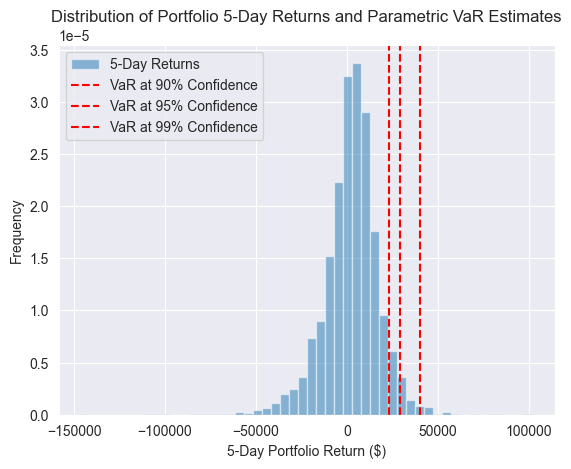

In [48]:
# Plot the Distribution of Portfolio Returns and Parametric VaR Estimates
# Convert returns to dollar values for the histogram
historical_x_day_returns_dollar = historical_x_day_returns * portfolio_value

# Plot the histogram
plt.hist(historical_x_day_returns_dollar, bins=50, density=True, alpha=0.5, label=f'{days}-Day Returns')

# Add vertical lines representing VaR at each confidence level
for cl, VaR in zip(confidence_levels, VaRs):
    plt.axvline(x=-VaR, linestyle='--', color='r', label='VaR at {}% Confidence'.format(int(cl * 100)))

plt.xlabel(f'{days}-Day Portfolio Return ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}-Day Returns and Parametric VaR Estimates')
plt.legend()
plt.show()